# Morphological-Image-Processing-Using-Python

In [154]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [156]:
def load_img():
    blank_img =np.zeros((600,600))
    font =cv2.FONT_HERSHEY_COMPLEX
    cv2.putText(blank_img,text='VIVO',org=(110,357), fontFace=font,fontScale= 5,color=(255,255,255),thickness=25,lineType=cv2.LINE_AA)
    return blank_img

In [157]:
def display_img(img):
    fig = plt.figure(figsize=(12,10))
    ax = fig.add_subplot(111)
    ax.imshow(img,cmap='gray')
    plt.show()

In [158]:
img = load_img()

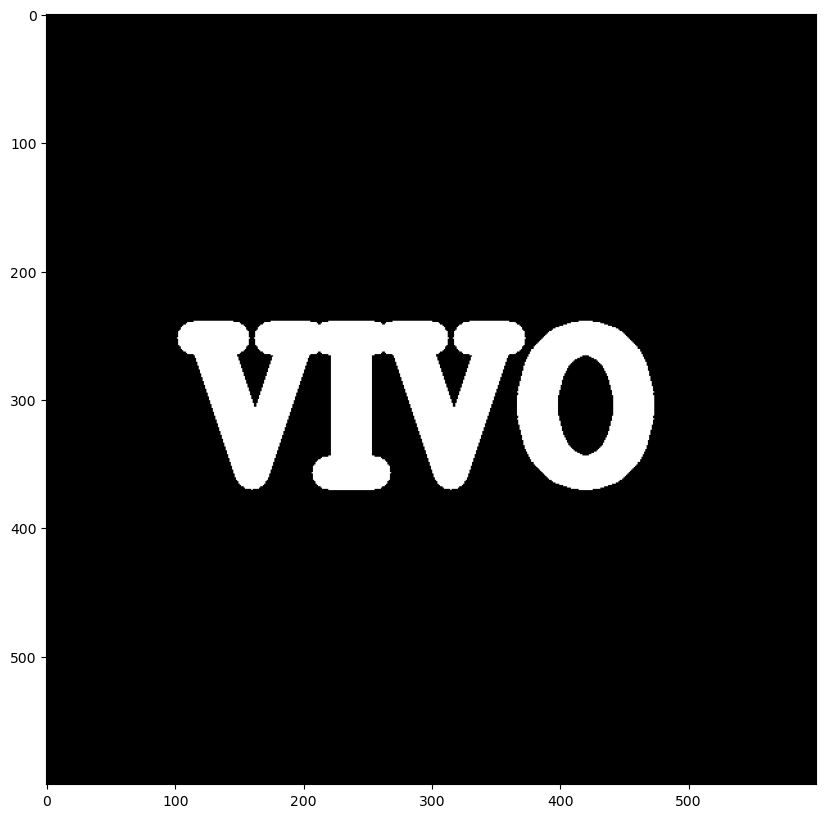

In [159]:
display_img(img)

## Erosion

Erodes away boundaries of foreground objects. Works best when foreground is light color (preferrably white) and background is dark.

In [161]:
kernel = np.ones((5,5), dtype=np.uint8)

In [162]:
kernel

array([[1, 1, 1, 1, 1],
       [1, 1, 1, 1, 1],
       [1, 1, 1, 1, 1],
       [1, 1, 1, 1, 1],
       [1, 1, 1, 1, 1]], dtype=uint8)

In [164]:
erosion1 = cv2.erode(img, kernel, iterations=1)

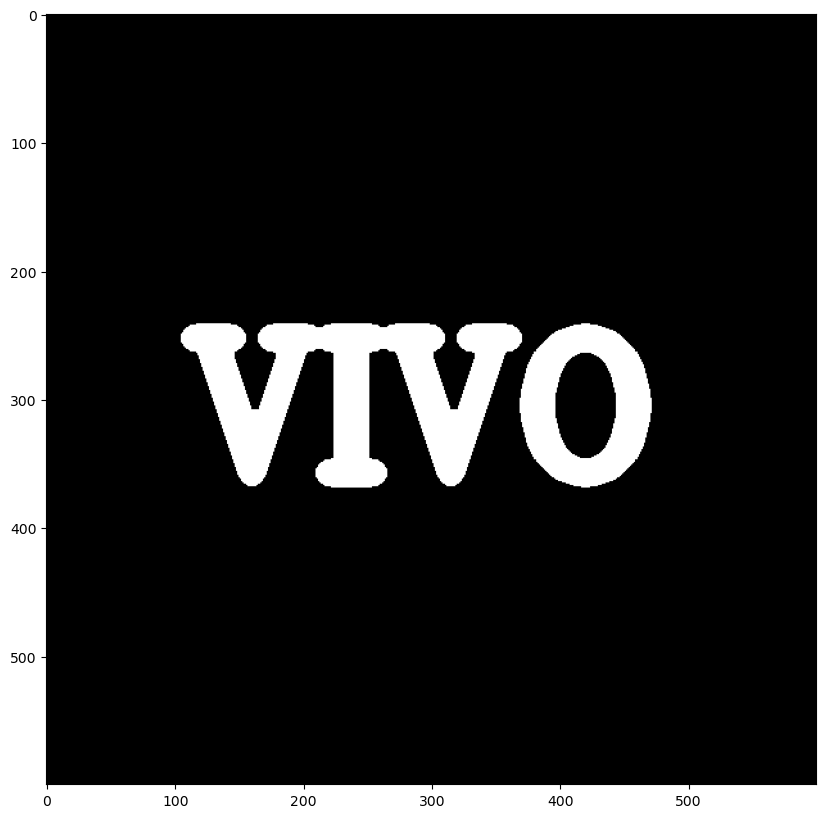

In [165]:
display_img(erosion1)

## Opening
Opening is erosion followed by dilation. Useful in removing background noise!

In [166]:
img = load_img()

In [167]:
white_noise = np.random.randint(low=0, high=3, size=(600,600,))

In [168]:
white_noise  # Display

array([[0, 1, 1, ..., 1, 1, 2],
       [2, 1, 0, ..., 1, 2, 0],
       [2, 2, 0, ..., 2, 0, 1],
       ...,
       [1, 2, 1, ..., 1, 1, 1],
       [1, 1, 1, ..., 0, 1, 1],
       [2, 1, 1, ..., 0, 0, 1]], shape=(600, 600), dtype=int32)

In [169]:
white_noise = white_noise*255

In [170]:
white_noise # Display 

array([[  0, 255, 255, ..., 255, 255, 510],
       [510, 255,   0, ..., 255, 510,   0],
       [510, 510,   0, ..., 510,   0, 255],
       ...,
       [255, 510, 255, ..., 255, 255, 255],
       [255, 255, 255, ...,   0, 255, 255],
       [510, 255, 255, ...,   0,   0, 255]], shape=(600, 600), dtype=int32)

In [171]:
noise_img = white_noise+img

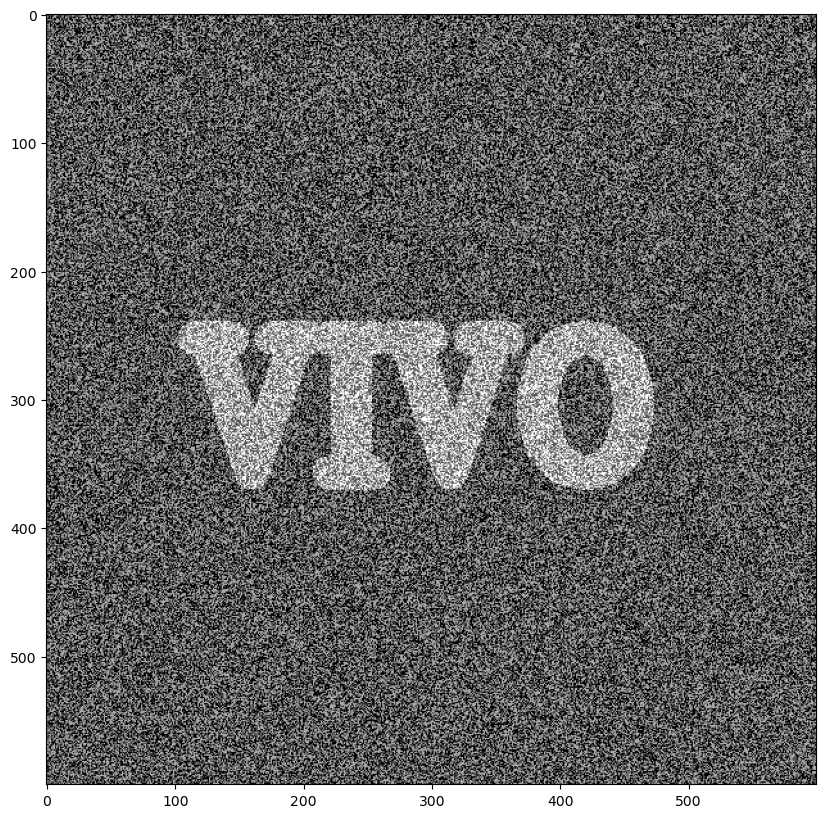

In [172]:
display_img(noise_img)   

In [173]:
opening = cv2.morphologyEx(noise_img, cv2.MORPH_OPEN, kernel)

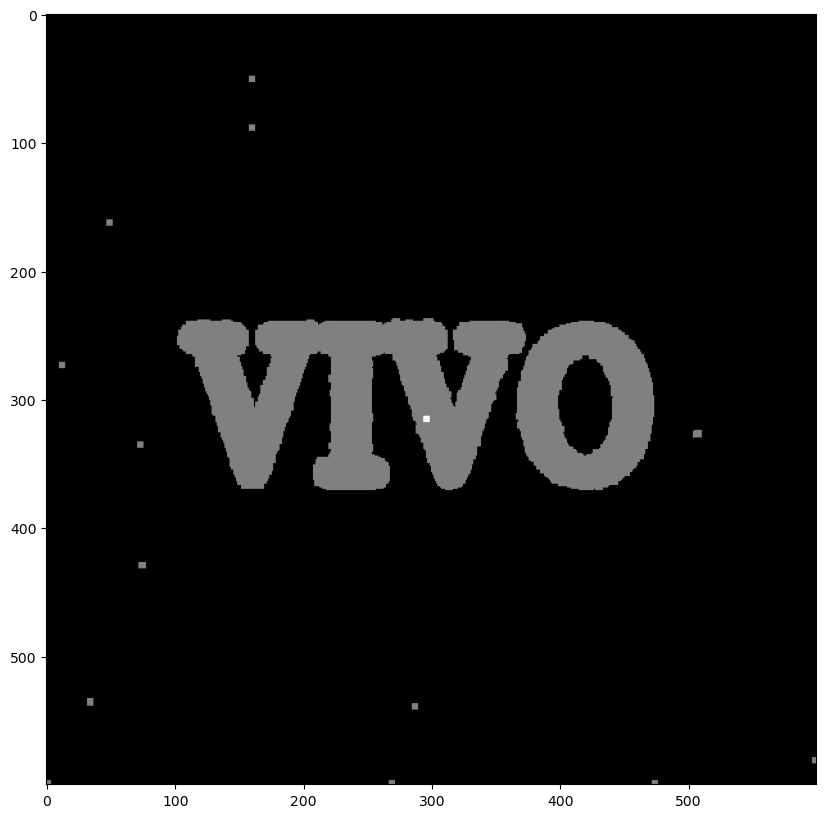

In [174]:
display_img(opening)

### Closing
 Useful in removing noise from foreground objects, such as black dots on top of the white text.

In [101]:
img = load_img()

In [175]:
black_noise = np.random.randint(low=0,high=2,size=(600,600))

In [176]:
black_noise

array([[0, 0, 1, ..., 1, 1, 1],
       [0, 1, 1, ..., 0, 1, 0],
       [1, 1, 0, ..., 0, 1, 1],
       ...,
       [1, 0, 1, ..., 1, 0, 1],
       [1, 0, 0, ..., 0, 0, 0],
       [0, 0, 1, ..., 1, 1, 1]], shape=(600, 600), dtype=int32)

In [177]:

black_noise= black_noise * -255

In [178]:
black_noise_img = img + black_noise

In [179]:
black_noise_img     # display

array([[   0.,    0., -255., ..., -255., -255., -255.],
       [   0., -255., -255., ...,    0., -255.,    0.],
       [-255., -255.,    0., ...,    0., -255., -255.],
       ...,
       [-255.,    0., -255., ..., -255.,    0., -255.],
       [-255.,    0.,    0., ...,    0.,    0.,    0.],
       [   0.,    0., -255., ..., -255., -255., -255.]], shape=(600, 600))

In [180]:
black_noise_img[black_noise_img==-255] = 0

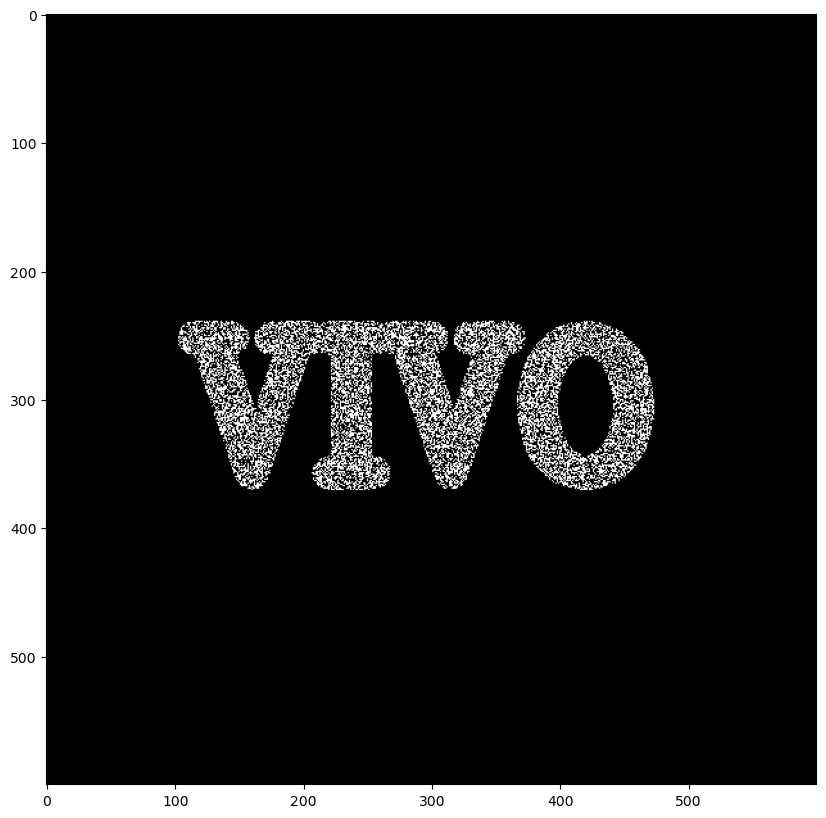

In [181]:
display_img(black_noise_img)

In [182]:
closing = cv2.morphologyEx(black_noise_img, cv2.MORPH_CLOSE, kernel)

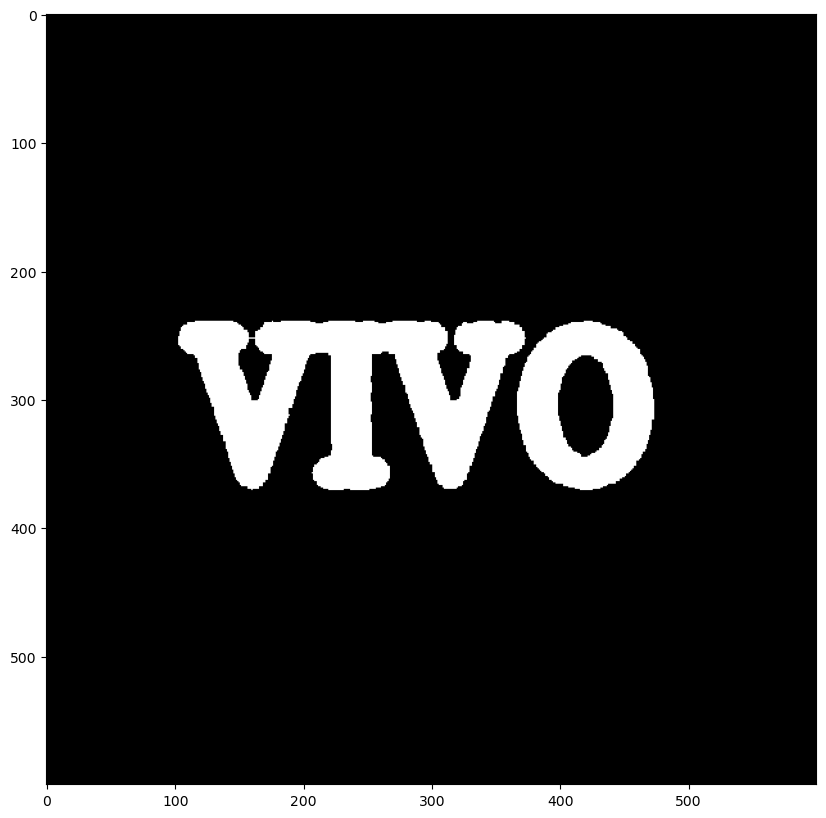

In [183]:
display_img(closing)

## Morphological Gradient

Difference between dilation and erosion of an image.

In [184]:
img = load_img()

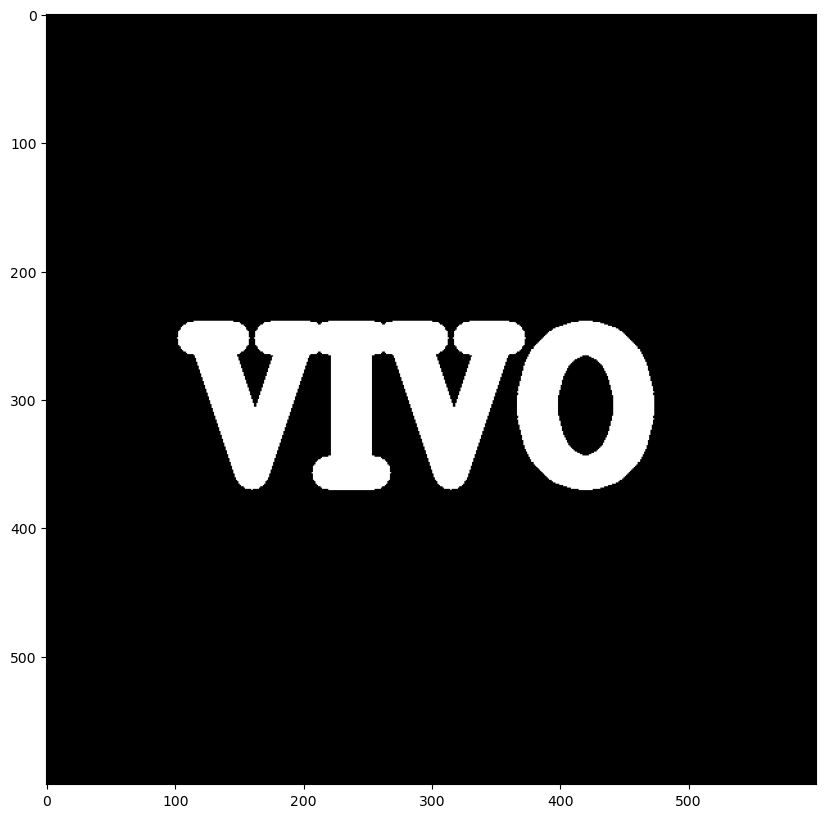

In [185]:
display_img(img)

In [186]:
gradient = cv2.morphologyEx(img,cv2.MORPH_GRADIENT,kernel)

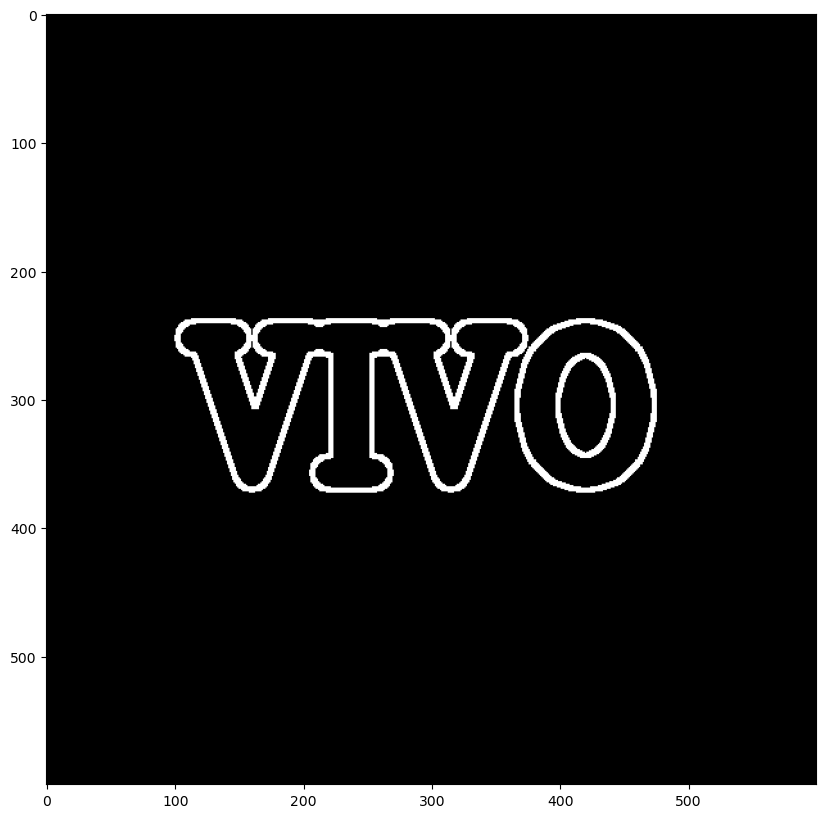

In [187]:
display_img(gradient)